### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

(np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan), np.int64(133), np.int64(0), np.float32(418.9276))
[   0 3072    0 ... 2052    0  516]
[       0     3072        0      512        0        0        0        0
 50331652     1536]
[       0 50331652        0     2048        0  2097152     3072     2052
        0      516]


<function matplotlib.pyplot.show(close=None, block=None)>

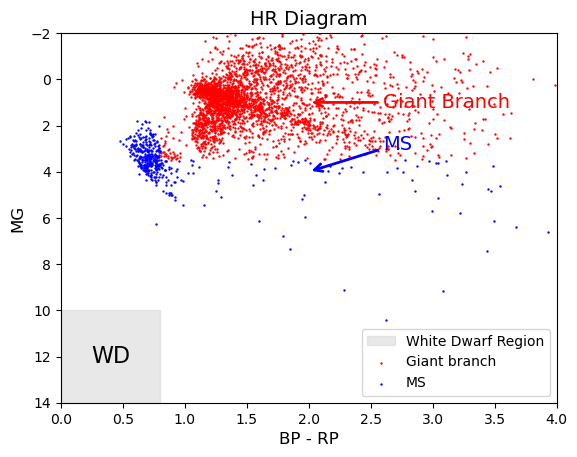

In [31]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names



mask1 = ((data['STARFLAG'] == 0) & #creating a mask to filter the data
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG'])))

clean_data = data[mask1]

n = len(clean_data)
indices = np.random.choice(n, int(0.02 * n), replace=False) #using 2% of the data as 80% makes the arrows invisible
data_80 = clean_data[indices]

para=data_80['GAIAEDR3_PARALLAX']
mg=data_80['GAIAEDR3_PHOT_G_MEAN_MAG']
Mg=mg+(5*np.log10(para/1000))+5 #converting into absolute mag

x= data_80['GAIAEDR3_PHOT_BP_MEAN_MAG']-data_80['GAIAEDR3_PHOT_RP_MEAN_MAG']

mask2= ((x>0.8)&(Mg<3.5))

print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"


plt.annotate('MS', #making the arrows match teh original diagram
             xy=(2.0, 4.0),#point on the same position
             xytext=(2.6, 2.8),#text pos
             fontsize=14,        
             color='blue',
             va='center',         
             ha='left',
             arrowprops=dict(
                 arrowstyle="->",
                 color='blue', 
                 lw=2,             ))

plt.annotate("Giant Branch",
             xy=(2.0, 1.0), 
             xytext=(2.6, 1.0),       
             fontsize=14, 
             color='red',     
             va='center', 
             ha='left', 
             arrowprops=dict(
                 arrowstyle="->", 
                 color='red', 
                 lw=2,
             ))



xwd= np.linspace(0, 0.8, 10) #x values formatching the requirements 

plt.fill_between(xwd, 10, 16, # y1=10 is the top boundary (faintest limit)
                 color='lightgray', # y2=16 is the bottom boundary
                 alpha=0.5, 
                 label='White Dwarf Region')



plt.scatter(x[mask2], Mg[mask2], color='r', label='Giant branch', s=0.5)
plt.scatter(x[~mask2], Mg[~mask2], color='b', label='MS', s=0.5)
plt.text(0.4, 12, 'WD', fontsize=16, ha='center', va='center')
plt.xlim(0, 4)
plt.ylim(14, -2)
plt.legend()
plt.xlabel('BP - RP', fontsize= 12)
plt.ylabel('MG', fontsize=12)
plt.title('HR Diagram', fontsize=14)
plt.show